In [1]:
library(DESeq2)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which, which.max, which.min



Attaching package: ‘S4Vectors’


The

In [3]:
## 数据预处理
sampleNames <- c("2Mock-1","2BE4-All-1","BE4-1","BE4-2","BE4-0706")

In [101]:
# 第一行是命令信息，所以跳过
data <- read.table("./all_feature.txt", header=TRUE, quote="\t", skip=1)
# data

In [100]:
# 前六列分别是Geneid	Chr	Start	End	Strand	Length
# 我们要的是count数，所以从第七列开始，一共有5列信息需要比较，所以是5+7-1=11
names(data)[7:11] <- sampleNames
countData <- as.matrix(data[7:11])
rownames(countData) <- data$Geneid

# countData

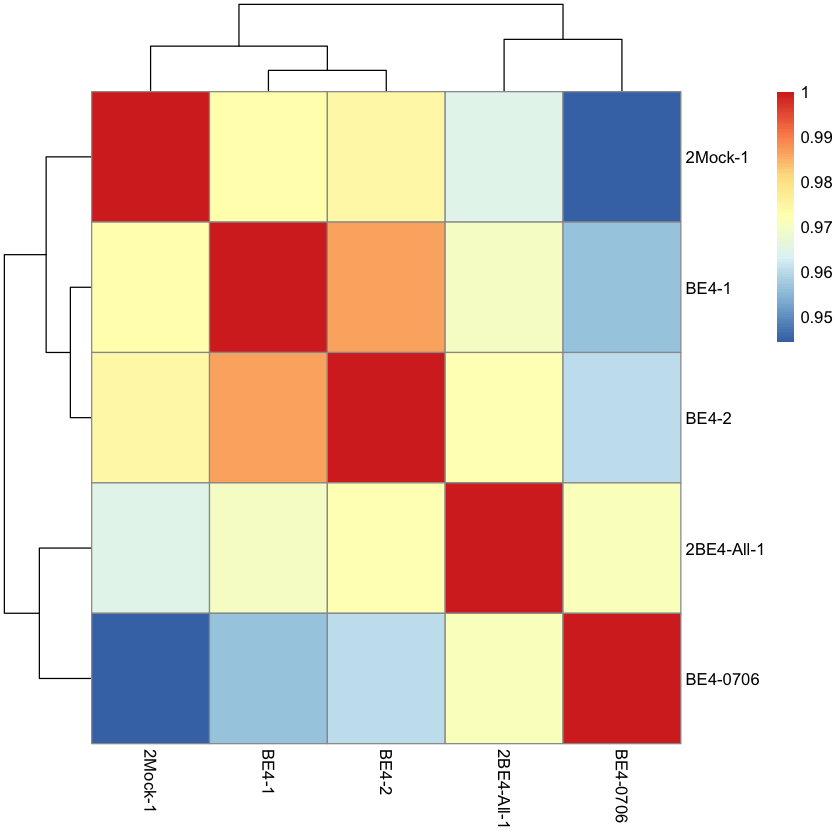

In [114]:

pheatmap(cor(log2(countData+1)))

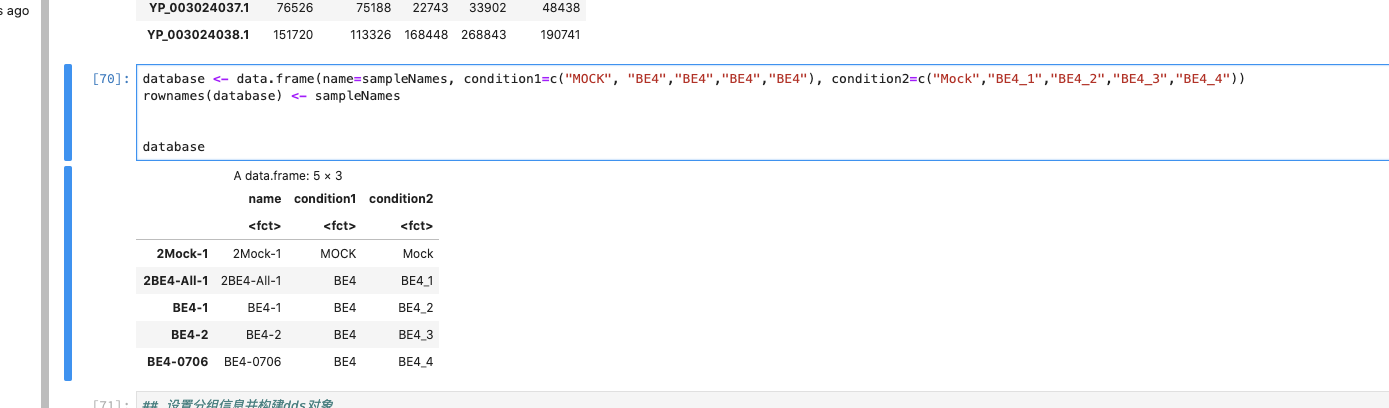

In [107]:
# database <- data.frame(name=sampleNames, condition=c("MOCK", "BE4","BE4","BE4","BE4"))
# rownames(database) <- sampleNames


database2 <- data.frame(name=sampleNames, condition=c("2Mock_1","2BE4_All_1","BE4_1","BE4_2","BE4_0706"))
rownames(database2) <- sampleNames
database2

,name,condition
,<fct>,<fct>
2Mock-1,2Mock-1,2Mock_1
2BE4-All-1,2BE4-All-1,2BE4_All_1
BE4-1,BE4-1,BE4_1
BE4-2,BE4-2,BE4_2
BE4-0706,BE4-0706,BE4_0706


In [108]:
## 设置分组信息并构建dds对象
# dds <- DESeqDataSetFromMatrix(countData, colData=database, design= ~ condition)
dds <- DESeqDataSetFromMatrix(countData, colData=database2, design= ~ condition)

dds <- dds[ rowSums(counts(dds)) > 1, ]



dds

class: DESeqDataSet 
dim: 25540 5 
metadata(1): version
assays(1): counts
rownames(25540): NR_024540.1 NR_106918.1 ... YP_003024037.1
  YP_003024038.1
rowData names(0):
colnames(5): 2Mock-1 2BE4-All-1 BE4-1 BE4-2 BE4-0706
colData names(2): name condition

In [111]:
## 使用DESeq函数估计离散度，然后差异分析获得res对象
dds <- DESeq(dds)
res <- results(dds, contrast=c("condition","2Mock_1","2BE4_All_1"))
# res <- results(dds, contrast=c("condition2","MOCK","BE4_1"))

estimating size factors

estimating dispersions



ERROR: Error in checkForExperimentalReplicates(object, modelMatrix): 

  The design matrix has the same number of samples and coefficients to fit,
  so estimation of dispersion is not possible. Treating samples
  as replicates was deprecated in v1.20 and no longer supported since v1.22.




In [86]:
dds

class: DESeqDataSet 
dim: 25540 5 
metadata(1): version
assays(4): counts mu H cooks
rownames(25540): NR_024540.1 NR_106918.1 ... YP_003024037.1
  YP_003024038.1
rowData names(22): baseMean baseVar ... deviance maxCooks
colnames(5): 2Mock-1 2BE4-All-1 BE4-1 BE4-2 BE4-0706
colData names(4): name condition1 condition2 sizeFactor

In [87]:
res

log2 fold change (MLE): condition1 MOCK vs BE4 
Wald test p-value: condition1 MOCK vs BE4 
DataFrame with 25540 rows and 6 columns
                        baseMean     log2FoldChange             lfcSE
                       <numeric>          <numeric>         <numeric>
NM_001964.2     11299.7558034073  -6.74151085235234 0.696611158466206
NM_005252.3     3929.86158949339  -6.70319732431564 0.763923493771627
NM_004454.2     266.756398240813  -4.59275939239605 0.793789650987934
NM_005346.4     54330.2821261773  -4.77716922346381 0.825674653187124
NR_130929.1      347.69913218188   2.64256793184879  0.48725978219014
...                          ...                ...               ...
NR_039991.1     2.84131288804152 -0.170133868696924  2.36455414417566
NM_001184797.1 0.354999884463188  -1.64051140331301  5.58232061567955
NM_001304990.1  5.40940888166733  -1.24285747541452  1.70970778207158
NR_028062.1     1.05206988160588  0.908650884707874  3.63952851934924
NR_033667.1    0.401188449295

In [88]:
table(res$padj<0.05) #取P值小于0.05的结果
res <- res[order(res$padj),]
diff_gene_deseq2 <-subset(res,padj < 0.05 & (log2FoldChange > 1 | log2FoldChange < -1))
diff_gene_deseq2


FALSE  TRUE 
11097    82 

log2 fold change (MLE): condition1 MOCK vs BE4 
Wald test p-value: condition1 MOCK vs BE4 
DataFrame with 82 rows and 6 columns
                    baseMean    log2FoldChange             lfcSE
                   <numeric>         <numeric>         <numeric>
NM_001964.2 11299.7558034073 -6.74151085235234 0.696611158466206
NM_005252.3 3929.86158949339 -6.70319732431564 0.763923493771627
NM_004454.2 266.756398240813 -4.59275939239605 0.793789650987934
NM_005346.4 54330.2821261773 -4.77716922346381 0.825674653187124
NR_130929.1  347.69913218188  2.64256793184879  0.48725978219014
...                      ...               ...               ...
NM_002299.3 45.7836243487902 -8.50515689924706  2.34366226509888
NR_027258.1 150.779197267681   1.9116475749427  0.52970319548533
NR_135128.1  304.65640955987  2.29223959666301 0.639108642835142
NM_002084.3 2123.74662549718 -1.86389514612821 0.520573960328895
NM_001197.4  62.201962774442  -2.9995429444235 0.840058181718243
                         st

In [89]:
write.csv(res, "res_des_output.csv")
resdata <- merge(as.data.frame(res), as.data.frame(counts(dds, normalized=TRUE)),by="row.names",sort=FALSE)
write.csv(resdata, "all_des_output.csv", row.names=FALSE)

In [90]:
# 输出两个文件，一个只有差异统计的结果，一个包含各个样本的结果。 这样就完成了DESeq2了。
# 接下来是作图： 一、MA图 MA图是拿来展示数据表达是否异常，现在一般都不用了。

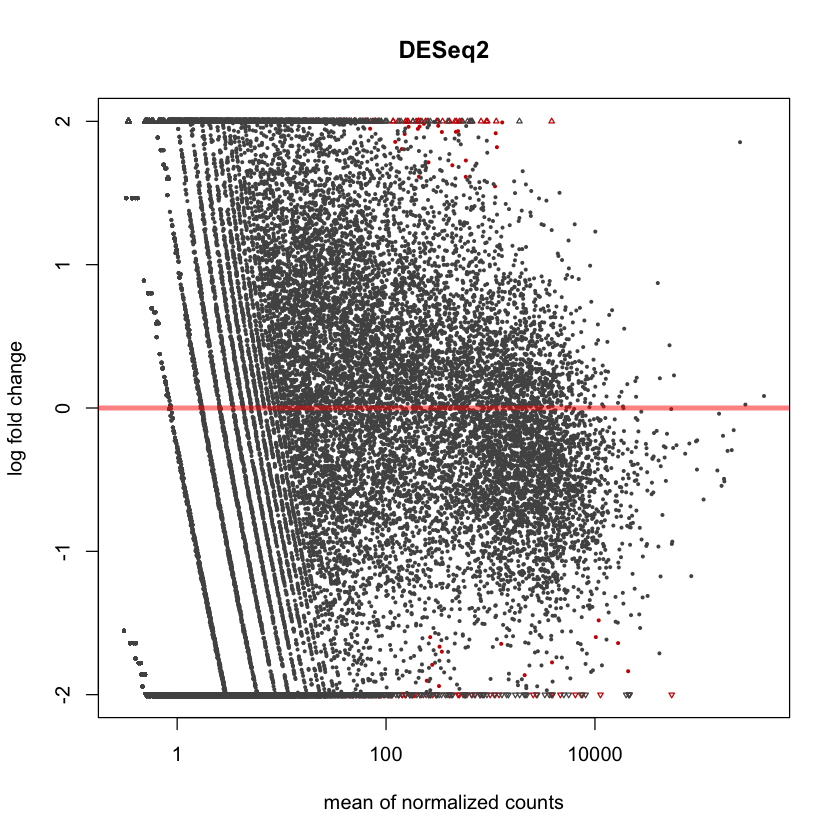

In [91]:
# library(DESeq2)
plotMA(res, main="DESeq2", ylim=c(-2, 2))

In [92]:
# 二、火山图 可以非常直观且合理地筛选出在两样本间发生差异表达的基因。

Warning message:
“Removed 14361 rows containing missing values (geom_point).”


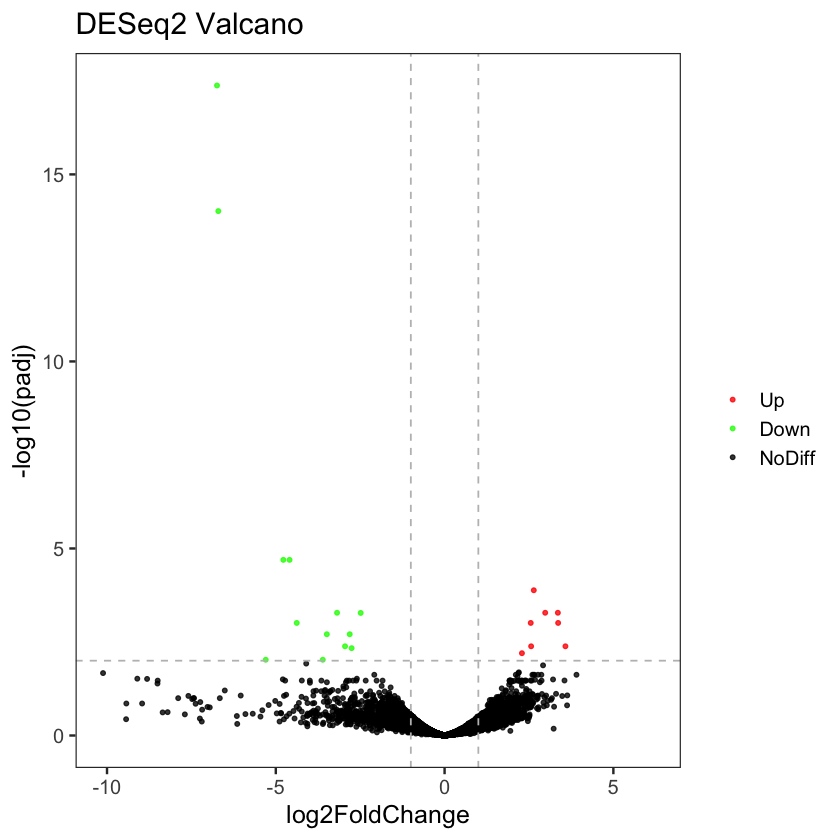

In [93]:
library(ggplot2)

# 这里的resdata也可以用res_des_output.csv这个结果重新导入哦。
# 现在就是用的前面做DESeq的时候的resdata。
resdata$change <- as.factor(
	ifelse(
		resdata$padj<0.01 & abs(resdata$log2FoldChange)>1,
		ifelse(resdata$log2FoldChange>1, "Up", "Down"),
		"NoDiff"
	)
)
valcano <- ggplot(data=resdata, aes(x=log2FoldChange, y=-log10(padj), color=change)) + 
	geom_point(alpha=0.8, size=1) + 
	theme_bw(base_size=15) + 
	theme(
		panel.grid.minor=element_blank(),
		panel.grid.major=element_blank()
	) + 
	ggtitle("DESeq2 Valcano") + 
	scale_color_manual(name="", values=c("red", "green", "black"), limits=c("Up", "Down", "NoDiff")) + 
	geom_vline(xintercept=c(-1, 1), lty=2, col="gray", lwd=0.5) + 
	geom_hline(yintercept=-log10(0.01), lty=2, col="gray", lwd=0.5)

valcano


In [94]:
# 三、PCA图 就是主成分分析。是把数据降维之后进行分析。PC1和PC2分别是贡献率第一的主成分和贡献率第二的主成分。

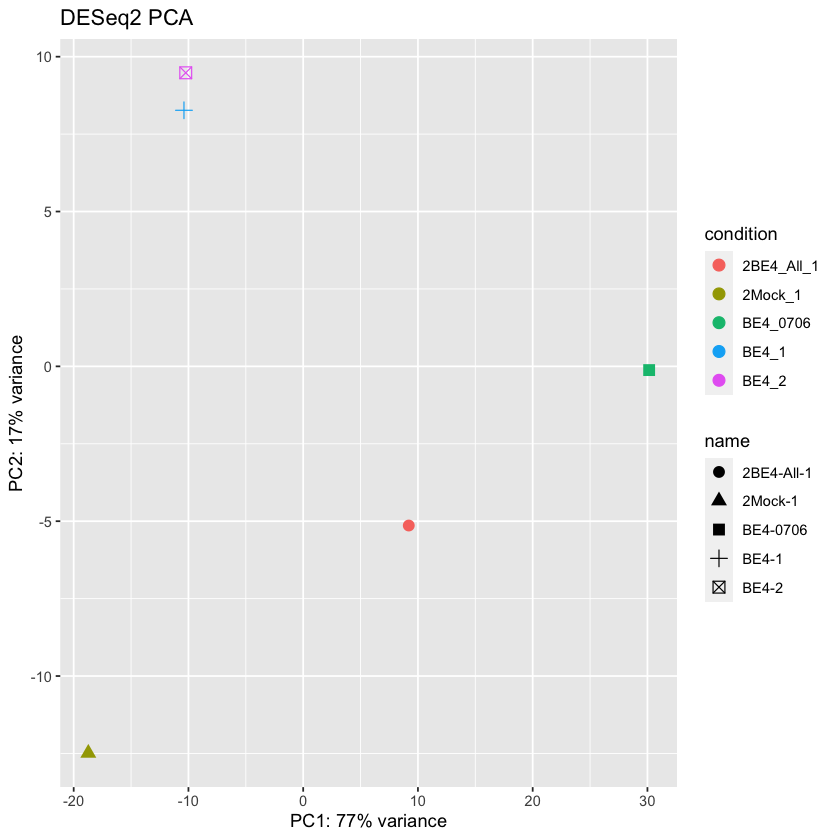

In [115]:
# library(ggplot2)
rld <- rlog(dds)
pcaData <- plotPCA(rld, intgroup=c("condition", "name"), returnData=T)
percentVar <- round(100*attr(pcaData, "percentVar"))
pca <- ggplot(pcaData, aes(PC1, PC2, color=condition, shape=name)) + 
	geom_point(size=3) + 
	ggtitle("DESeq2 PCA") + 
	xlab(paste0("PC1: ", percentVar[1], "% variance")) + 
	ylab(paste0("PC2: ", percentVar[2], "% variance"))
pca

In [117]:
# 四、热图 heatmap 实现这基因表达模式可视化的需求。 从这里可以看到这6个样本的表达差异。

In [118]:
library(pheatmap)

select <- order(rowMeans(counts(dds, normalized=T)), decreasing=T)[1:80]
nt <- normTransform(dds)
log2.norm.counts <- assay(nt)[select,]
df <- as.data.frame(colData(dds)[, c("name", "condition")])
pheatmap(log2.norm.counts, scale="column", cluster_rows=T, show_rownames=F, cluster_cols=T, annotation_col=df, fontsize=14)

ERROR: Error in .local(object, ...): first calculate size factors, add normalizationFactors, or set normalized=FALSE


In [122]:
# GO KEGG GSEA 

In [120]:
## 2